In [2]:
import os
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import pearsonr
from tqdm import tqdm
import time
from collections import Counter
from matplotlib.patches import Patch
from scipy.spatial.distance import cdist
import re
import scipy
import warnings
from scipy.stats import median_abs_deviation

from scipy.stats import zscore
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import linkage, fcluster
from collections import defaultdict
from cuml.metrics import pairwise_distances

import rmm
import cupy
import cudf
import cupy as cp
# import cvxpy as cpv
from rmm.allocators.cupy import rmm_cupy_allocator
from sklearn.feature_extraction.text import CountVectorizer
from cuml.linear_model import ElasticNet
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scanpy.external as sce

sc.settings.verbosity = 2
sc.logging.print_header()

# import torch
# from torchnmf.nmf import NMF

# Enable `managed_memory`
if not rmm.is_initialized():
    rmm.reinitialize(managed_memory=True, pool_allocator=False)
    cp.cuda.set_allocator(rmm.rmm_cupy_allocator)

# Load in the data

In [3]:
start = time.perf_counter()

path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/raw_merged_gene_data.h5ad"

adata_raw = sc.read_h5ad(path)

sc.logging.print_memory_usage() 
print(f"Total time: {time.perf_counter() - start:.2f} seconds")

print(f"Initial shape: {adata_raw.shape}\n")
print(f"N cells in HYB dataset: {adata_raw[adata_raw.obs['dataset'] == 'Hybrid'].n_obs}")
print(f"N cells in scFib dataset: {adata_raw[adata_raw.obs['dataset'] == 'Control'].n_obs}\n")

adata_raw

Memory usage: current 1.20 GB, difference +1.20 GB
Total time: 1.18 seconds
Initial shape: (19858, 28702)

N cells in HYB dataset: 10895
N cells in scFib dataset: 8963



AnnData object with n_obs × n_vars = 19858 × 28702
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End'

In [4]:
### --- Handle HYB cells with NaN feature barcode predictions ---
init_cells_hybrid = adata_raw[adata_raw.obs['dataset'] == 'Hybrid'].n_obs

# remove HYB cells with NaN feature barcode predictions
hybrid_to_remove = (adata_raw.obs['dataset'] == 'Hybrid') & (adata_raw.obs['assigned_condition'].isna())
cells_to_keep = ~(hybrid_to_remove)
adata_raw = adata_raw[cells_to_keep].copy()

final_cells_hybrid = adata_raw[adata_raw.obs['dataset'] == 'Hybrid'].n_obs
removed_hybrid_cells = init_cells_hybrid - final_cells_hybrid

print(f"Removed {removed_hybrid_cells} 'Hybrid' cells with unassigned feature barcodes")
print(f"Final shape: {adata_raw.shape}")


### --- Add new column for grouping HYB cells vs Controls ---
adata_raw.obs['pooled_condition'] = adata_raw.obs['assigned_condition'].replace({
    "G1": "Control",
    "S": "Control",
    "G2M": "Control",
    "PRRX1": "siPRRX1",
    "PRRX1_MYOD": "siPRRX1/mmMYOD1",
    "MYOD": "mmMYOD1"
})

# fill remaining NaN feature barcode predictions (only control cells) with 'Control'
adata_raw.obs['pooled_condition'] = adata_raw.obs['pooled_condition'].fillna('Control')
print(adata_raw.obs['pooled_condition'].value_counts())

adata_raw

Removed 1 'Hybrid' cells with unassigned feature barcodes
Final shape: (19857, 28702)
pooled_condition
Control            8963
siPRRX1/mmMYOD1    4174
siPRRX1            3955
mmMYOD1            2765
Name: count, dtype: int64


/tmp/ipykernel_2238876/1807916870.py:17: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_raw.obs['pooled_condition'] = adata_raw.obs['assigned_condition'].replace({


AnnData object with n_obs × n_vars = 19857 × 28702
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End'

In [24]:
adata = adata_raw.copy()

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

adata

AnnData object with n_obs × n_vars = 19857 × 28702
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

## Cell filtering (MADs)

In [25]:
# Identify outlier cells with MADs per dataset
def is_outlier_by_group(adata, metric: str, nmads: int, group_col: str = 'dataset'):
    outlier_series = pd.Series(False, index=adata.obs.index)
    unique_groups = adata.obs[group_col].unique()

    for group in unique_groups:
        group_mask = (adata.obs[group_col] == group)
        M_group = adata.obs.loc[group_mask, metric]

        if len(M_group) < 2 or M_group.isnull().all():
            continue

        median_val_group = np.median(M_group)
        mad_val_group = median_abs_deviation(M_group)

        if mad_val_group == 0:
            continue

        outliers_in_group = (M_group < median_val_group - nmads * mad_val_group) | \
                            (median_val_group + nmads * mad_val_group < M_group)

        outlier_series.loc[group_mask] = outliers_in_group

    return outlier_series


adata.obs["outlier"] = (
    is_outlier_by_group(adata, "log1p_total_counts", 5, 'dataset')
    | is_outlier_by_group(adata, "log1p_n_genes_by_counts", 5, 'dataset')
)

print("Number of outlier cells per dataset based on counts:")
print(adata.obs.groupby('dataset', observed=True)['outlier'].sum())


adata.obs["mt_outlier"] = is_outlier_by_group(adata, "pct_counts_mt", 5, 'dataset') | (
    adata.obs["pct_counts_mt"] > 20
)

print("\nNumber of outlier cells per dataset based on pct mito:")
adata.obs.groupby('dataset', observed=True)['mt_outlier'].sum()

Number of outlier cells per dataset based on counts:
dataset
Hybrid     1184
Control    1676
Name: outlier, dtype: int64

Number of outlier cells per dataset based on pct mito:


dataset
Hybrid      788
Control    1852
Name: mt_outlier, dtype: int64

In [26]:
init_cells = adata.n_obs
init_cells_hyb = adata[adata.obs['dataset'] == 'Hybrid'].n_obs
init_cells_fib = adata[adata.obs['dataset'] == 'Control'].n_obs

print(f"Total number of cells: {init_cells}")
print(f"N cells in Hybird: {init_cells_hyb}")
print(f"N cells in Control: {init_cells_fib}")

print(f"\nFiltering...")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

final_cells = adata.n_obs
final_cells_hyb = adata[adata.obs['dataset'] == 'Hybrid'].n_obs
final_cells_fib = adata[adata.obs['dataset'] == 'Control'].n_obs


print(f"\nRemoved {init_cells - final_cells} total cells.")
print(f"Removed {init_cells_hyb - final_cells_hyb} from Hybrid dataset.")
print(f"Removed {init_cells_fib - final_cells_fib} from Control dataset.")


print(f"\nTotal cells after filtering of low quality cells: {final_cells}")
print(f"N cells in Hybird: {final_cells_hyb}")
print(f"N cells in Control: {final_cells_fib}")

Total number of cells: 19857
N cells in Hybird: 10894
N cells in Control: 8963

Filtering...

Removed 3490 total cells.
Removed 1487 from Hybrid dataset.
Removed 2003 from Control dataset.

Total cells after filtering of low quality cells: 16367
N cells in Hybird: 9407
N cells in Control: 6960


In [27]:
# keep full dimension safe
adata.raw = adata  

# save raw counts
adata.layers['raw_counts'] = adata.X.copy()

sc.pp.filter_genes(adata, min_counts=10)

sc.pp.normalize_total(
    adata,
    target_sum=1e4,
)

# save normalized counts
adata.layers['norm_counts'] = adata.X.copy()

# log transform normalized counts
sc.pp.log1p(adata)

# save log normalized counts
adata.layers['log_norm'] = adata.X.copy()

adata

filtered out 3576 genes that are detected in less than 10 counts
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 16367 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts'
    uns: 'log1p'
    layers: 'raw_counts', 'norm_counts', 'log_norm'

# HVGs

extracting highly variable genes
    finished (0:00:03)
Number of HVG: 2000


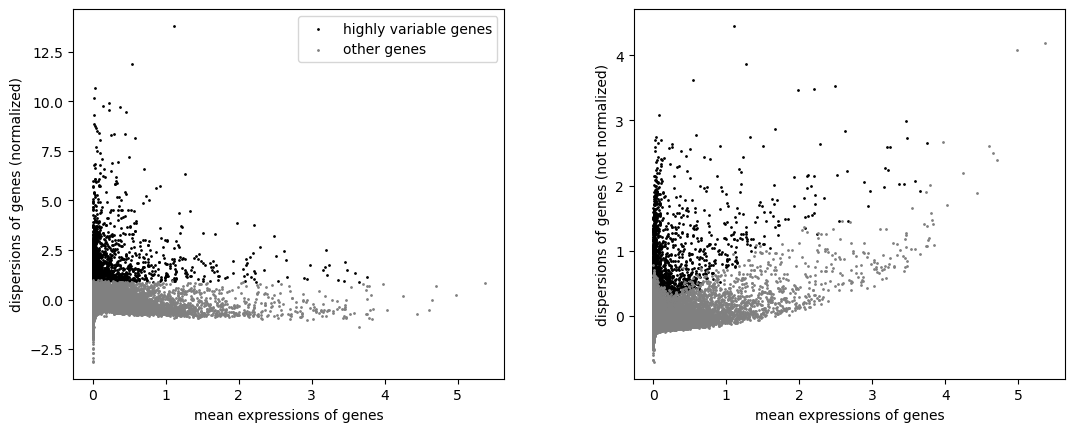

In [28]:
adata.X = adata.layers['log_norm']

sc.pp.highly_variable_genes(
    adata,
    batch_key='dataset',
    n_top_genes=2000, 
)

print(f"Number of HVG: {adata.var['highly_variable'].sum()}")

plt.rcdefaults()
sc.pl.highly_variable_genes(adata)

# PCA

computing PCA
    with n_comps=50
    finished (0:00:02)


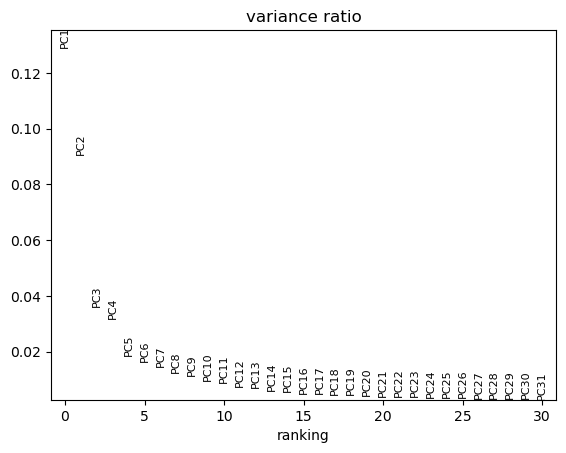

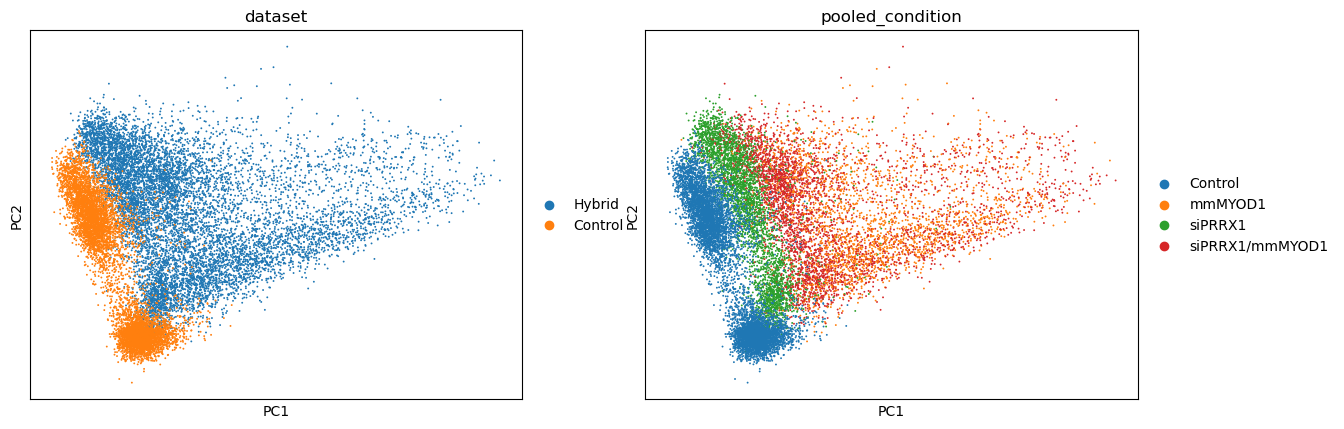

AnnData object with n_obs × n_vars = 16367 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'hig

In [29]:
sc.pp.pca(adata)

sc.pl.pca_variance_ratio(adata)
sc.pl.pca(adata, color=['dataset', 'pooled_condition'])

adata

# Harmony integration

2025-06-24 18:20:23,883 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-06-24 18:20:26,762 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-06-24 18:20:26,922 - harmonypy - INFO - Iteration 1 of 10
2025-06-24 18:20:31,036 - harmonypy - INFO - Iteration 2 of 10
2025-06-24 18:20:35,014 - harmonypy - INFO - Converged after 2 iterations


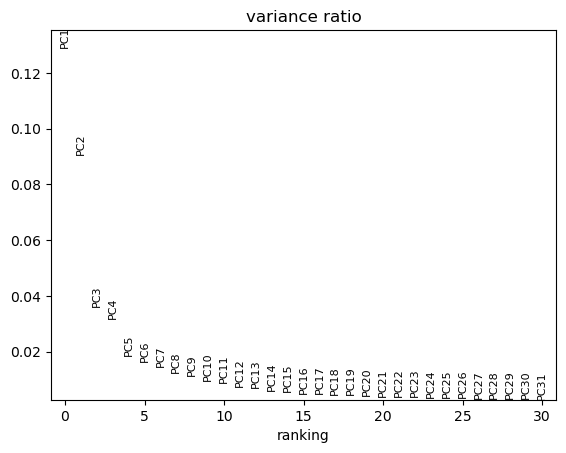

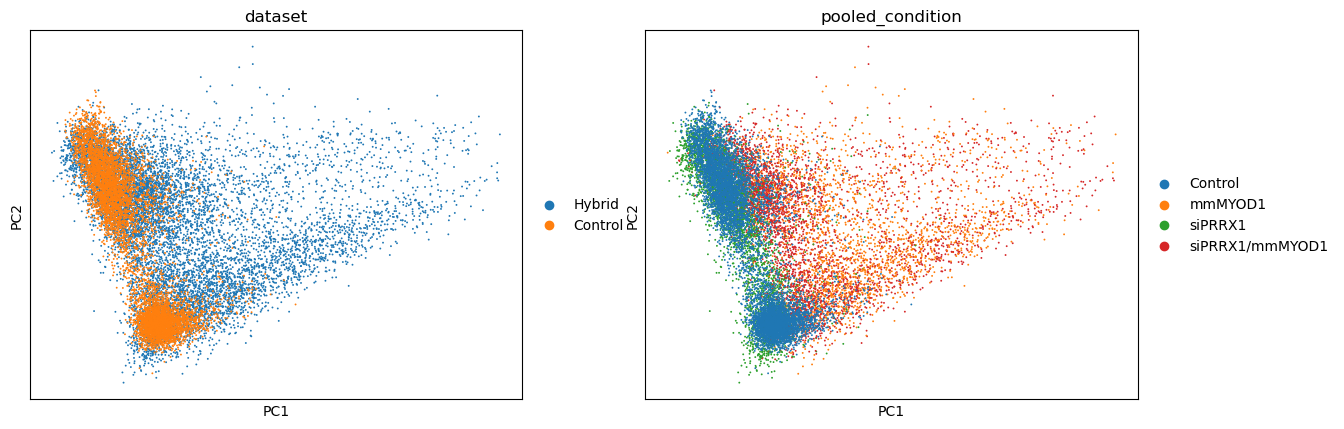

In [30]:
sce.pp.harmony_integrate(adata, 'dataset')

# Save original PCA space
adata.obsm["X_pca_original"] = adata.obsm["X_pca"].copy()

# Set Harmony-corrected PCA as the default for plotting and MAGIC imputation
adata.obsm["X_pca"] = adata.obsm["X_pca_harmony"].copy()

sc.pl.pca_variance_ratio(adata)
sc.pl.pca(adata, color=['dataset', 'pooled_condition'])

In [32]:
adata

AnnData object with n_obs × n_vars = 16367 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'hig

In [12]:
from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

running PAGA
    finished (0:00:00)


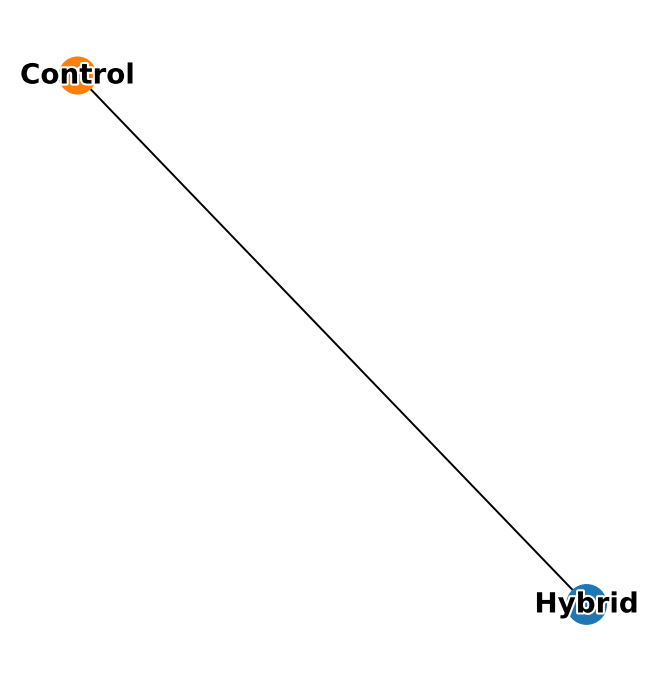

In [33]:
# sc.pp.neighbors(
#     adata,
#     use_rep='X_pca_harmony',
#     n_neighbors=10,
# )

sc.tl.paga(adata, groups='dataset')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4
sc.pl.paga(
    adata, 
    fontoutline=1.5, 
    edge_width_scale=0.25,  
    frameon=False,          
)

adata.obsm['X_paga'] = get_init_pos_from_paga(adata)

init_pos.shape=(16367, 2) type(init_pos)=<class 'numpy.ndarray'>
data.shape=(16367, 50) type(data)=<class 'numpy.ndarray'>
graph.shape=(16367, 16367) type(graph)=<class 'scipy.sparse._csr.csr_matrix'>
min_dist=1 spread=5 a=np.float64(0.04999630775526982) b=np.float64(1.0030054322546282)
computing UMAP


/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/scipy/optimize/_minpack_py.py:539: RuntimeWarning: divide by zero encountered in power
  return func(xdata, *params) - ydata


    finished (0:00:13)


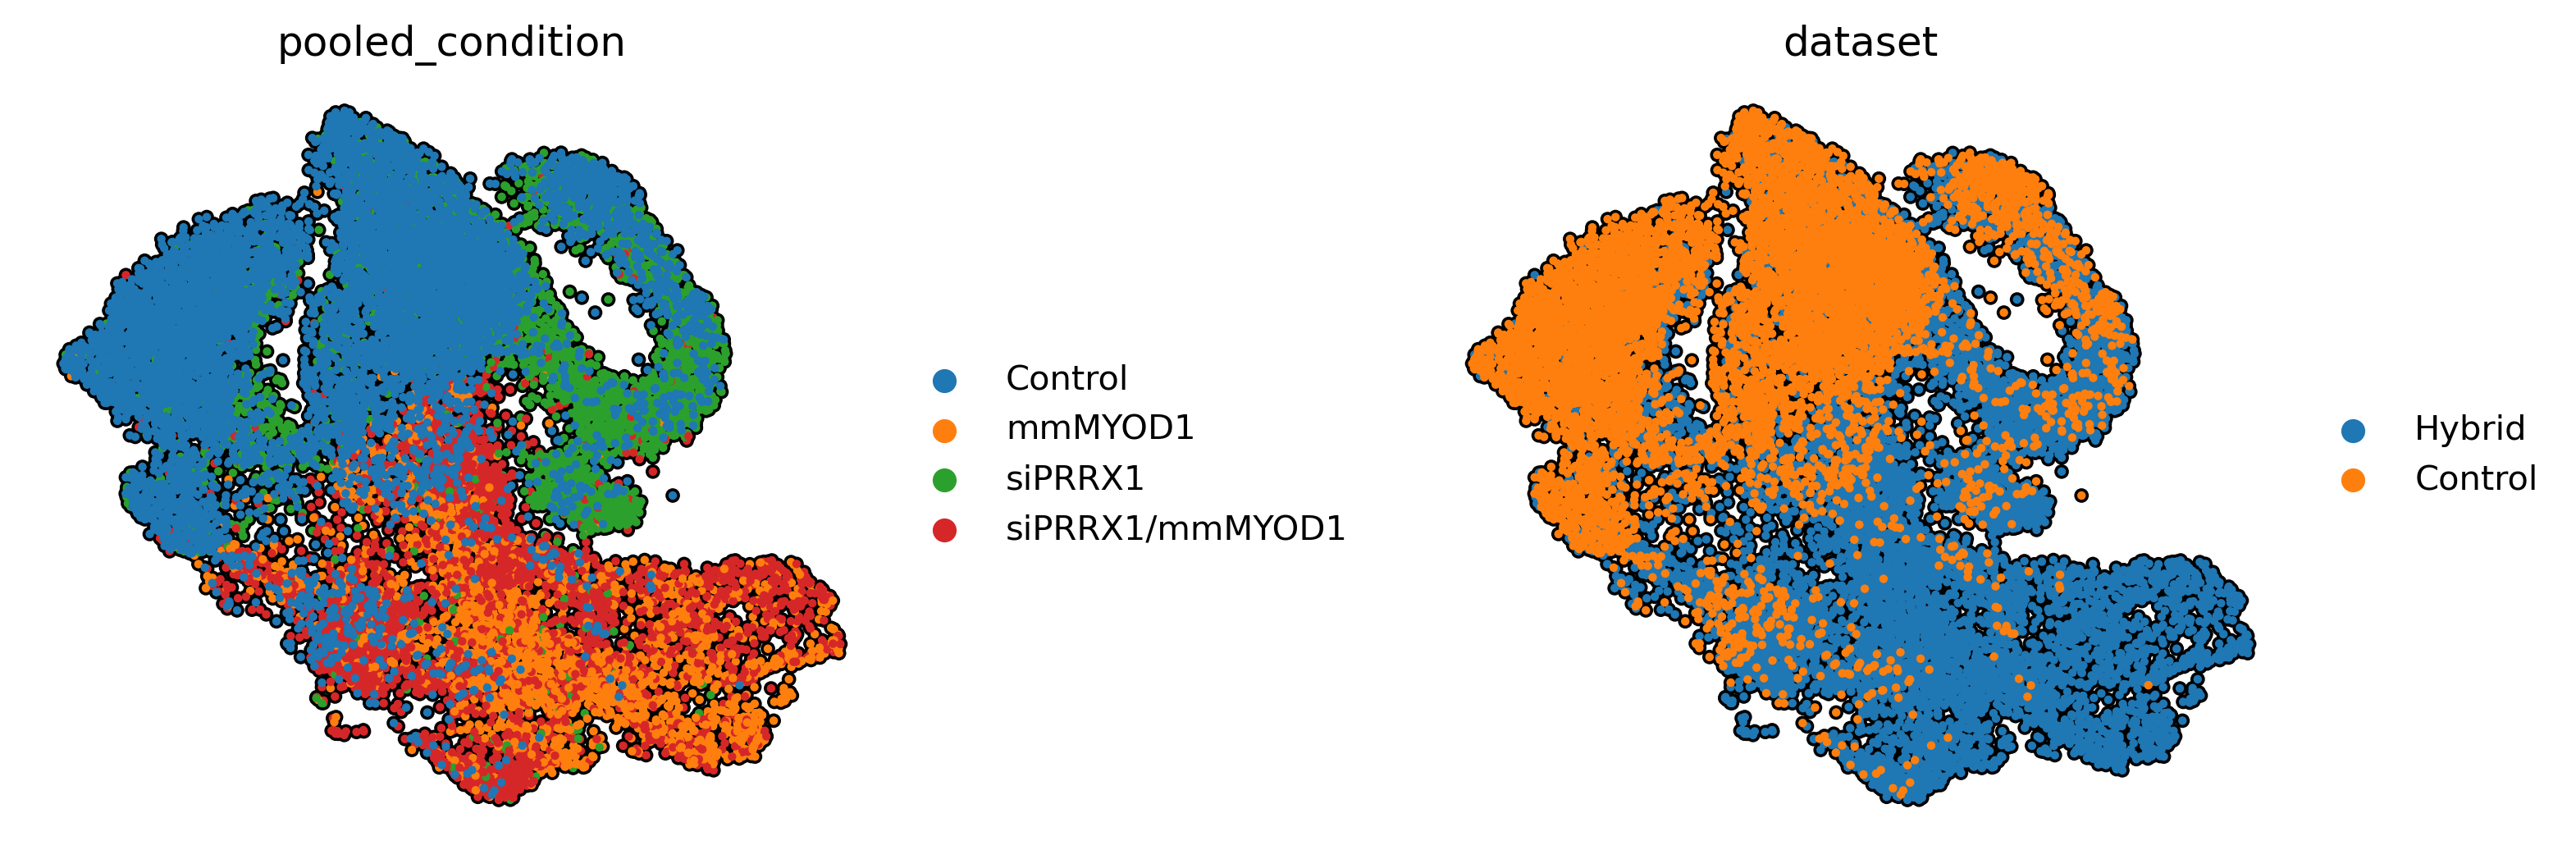

CPU times: user 14.9 s, sys: 34.3 ms, total: 14.9 s
Wall time: 14.9 s


In [34]:
%%time 

min_dist = 1
spread = 5

# get the inputs
init_pos = adata.obsm['X_paga']
data = adata.obsm['X_pca_harmony']
graph = adata.obsp['connectivities']

print(f"{init_pos.shape=} {type(init_pos)=}")
print(f"{data.shape=} {type(data)=}")
print(f"{graph.shape=} {type(graph)=}")

# find params
a, b = find_ab_params(spread=spread, min_dist=min_dist)
print(f"{min_dist=} {spread=} {a=} {b=}")


sc.tl.umap(
    adata,
    a=a,
    b=b,
    init_pos=init_pos,
    random_state=1729,
)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata, 
    color=['pooled_condition', 'dataset'], 
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

S phase genes: 43
G2M phase genes: 54
calculating cell cycle phase
computing score 'S_score'
    finished (0:00:01)
computing score 'G2M_score'
    finished (0:00:01)


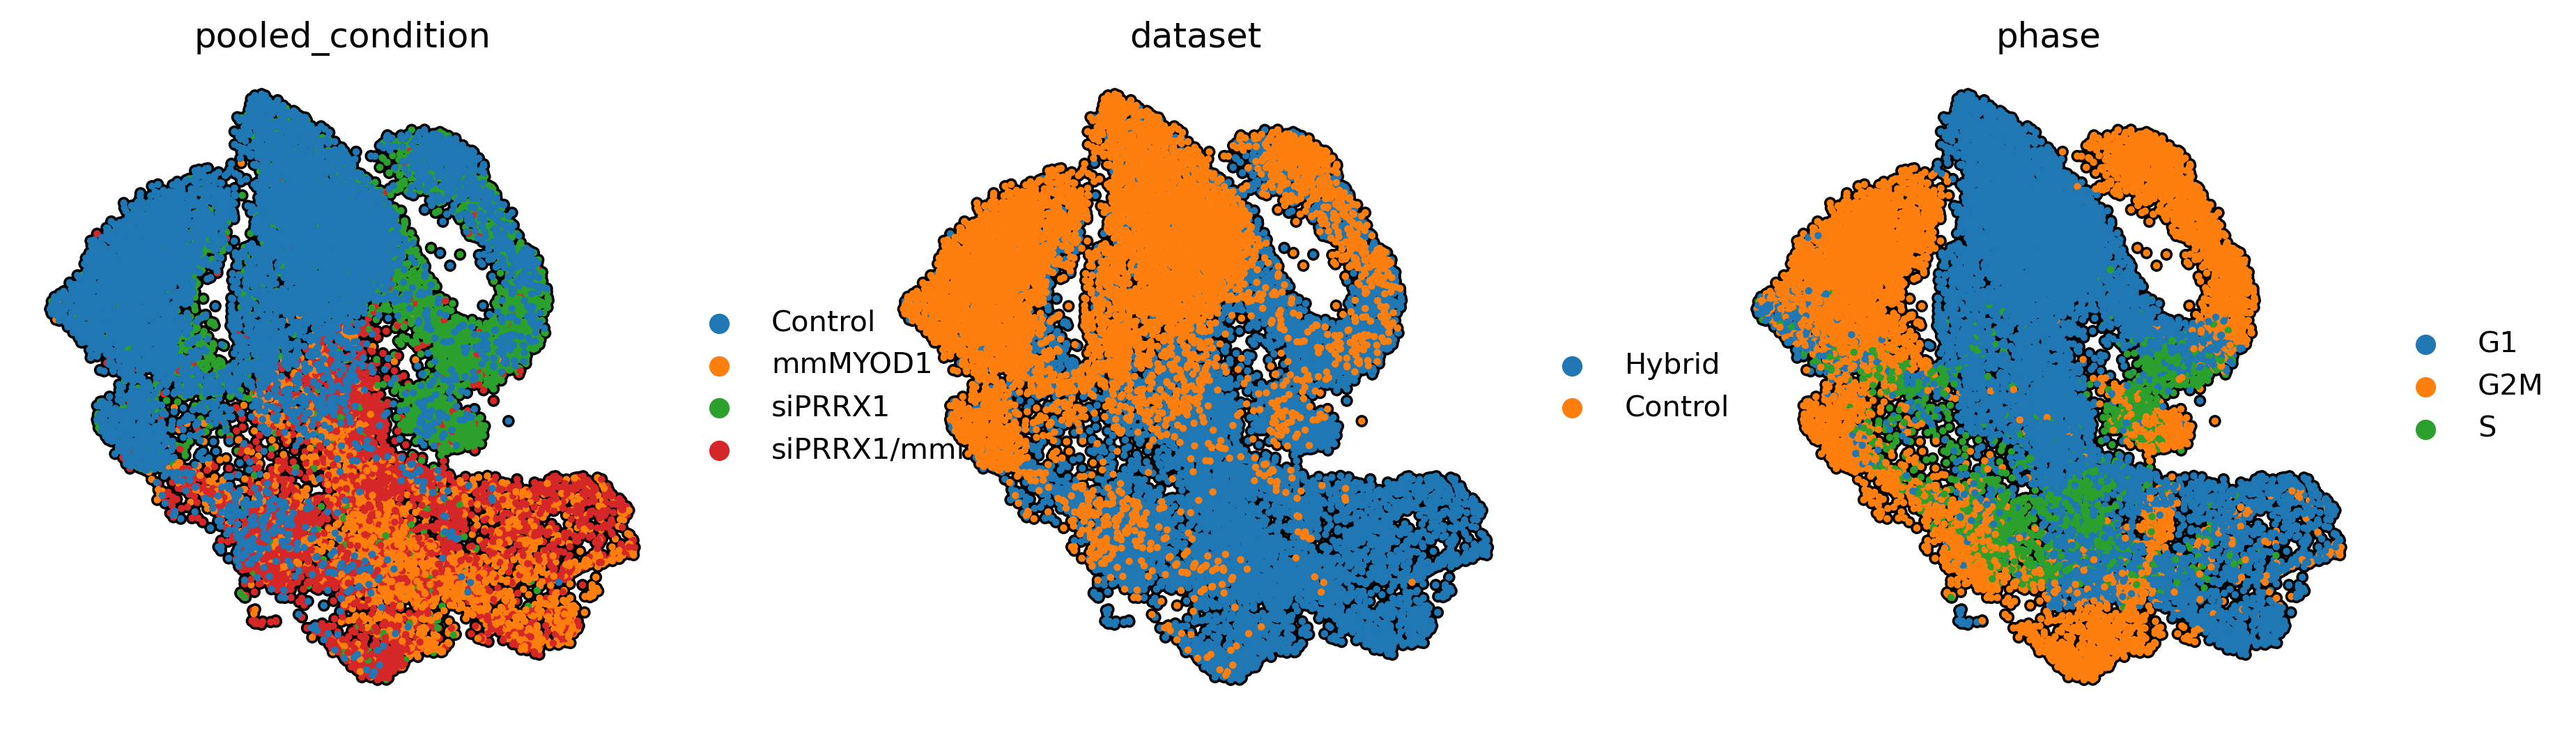

In [35]:
path = "/nfs/turbo/umms-indikar/Ram/projects/reprogramming/Genexpression/Pseudotime/data/regev_lab_cell_cycle_genes.txt"

cell_cycle_genes = [x.strip() for x in open(path)]

s_genes = cell_cycle_genes[:43]
print(f"S phase genes: {len(s_genes)}")

g2m_genes = cell_cycle_genes[43:]
print(f"G2M phase genes: {len(g2m_genes)}")

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata, 
    color=['pooled_condition', 'dataset', 'phase'], 
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    # wspace=0.5,
)

In [ ]:
rsc.get.anndata_to_CPU(adata)
rsc.get.anndata_to_GPU(adata)
# rsc.get.anndata_to_CPU(adata)

In [16]:
%%time 

min_dist = 1.0
spread = 5

# get the inputs
init_pos = adata.obsm['X_paga']
data = adata.obsm['X_pca_harmony']
graph = adata.obsp['connectivities']

print(f"{init_pos.shape=} {type(init_pos)=}")
print(f"{data.shape=} {type(data)=}")
print(f"{graph.shape=} {type(graph)=}")

# find params
a, b = find_ab_params(spread=spread, min_dist=min_dist)
print(f"{min_dist=} {spread=} {a=} {b=}")

# use simplicial_set_embedding
embedding = simplicial_set_embedding(
    data=data,
    graph=graph,
    a=a, b=b,
    n_components=2,
    init=init_pos,
    random_state=1729,
)

# store embedding
print(f"{embedding.shape=} {type(embedding)=}")
adata.obsm['X_umap'] = embedding.to_device_array().get().copy()

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata, 
    color=['pooled_condition', 'dataset'], 
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

init_pos.shape=(16367, 2) type(init_pos)=<class 'numpy.ndarray'>
data.shape=(16367, 50) type(data)=<class 'numpy.ndarray'>
graph.shape=(16367, 16367) type(graph)=<class 'scipy.sparse._csr.csr_matrix'>
min_dist=1.0 spread=5 a=np.float64(0.04999630775526982) b=np.float64(1.0030054322546282)


/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/scipy/optimize/_minpack_py.py:539: RuntimeWarning: divide by zero encountered in power
  return func(xdata, *params) - ydata


MemoryError: std::bad_alloc: CUDA error (failed to allocate 3273408 bytes) at: /home/jrcwycy/miniconda3/envs/rapids_singlecell/include/rmm/mr/device/cuda_memory_resource.hpp:62: cudaErrorDevicesUnavailable CUDA-capable device(s) is/are busy or unavailable

In [ ]:
sc.pp.neighbors(
    adata,
    use_rep='X_pca_harmony',
    n_neighbors=10,
)

# sc.tl.umap(
#     adata,
#     min_dist=0.2
# )

sc.tl.tsne(
    adata,
    

sc.tl.leiden(
    adata,
    resolution=0.4,
    flavor="igraph",
    n_iterations=-1, 
)

adata.obs['cluster_str'] = adata.obs['leiden'].apply(lambda x: f"C{str(int(x) + 1)}")

sc.pl.umap(
    adata,
    color=['dataset', 'pooled_condition', 'cluster_str', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_mt'],
    ncols=3,
    size=35,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)